<a href="https://colab.research.google.com/github/changsksu/IMSE_Data_Science/blob/main/NN_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

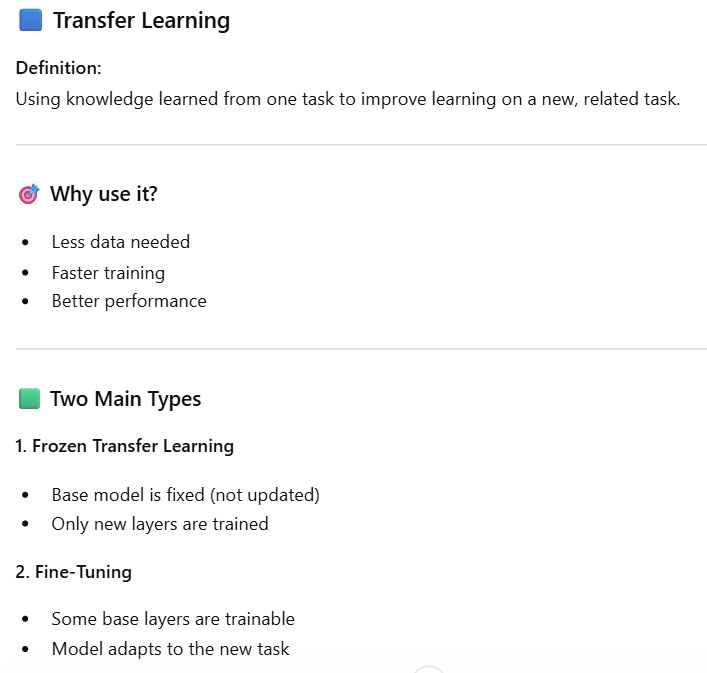

Key Idea

Reuse learned features → improve learning on new problems

# **Transfer Learning with Different Tasks**

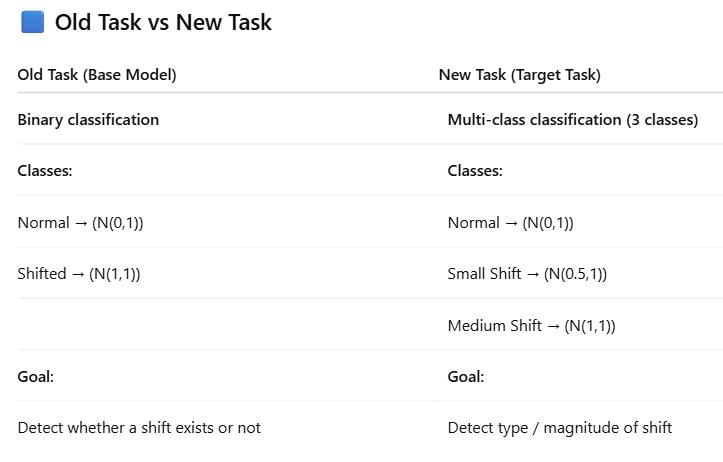

Key Point

👉 The two tasks are different in complexity and objective:

Old task: coarse decision (shift vs no shift)
New task: fine-grained decision (shift magnitude)

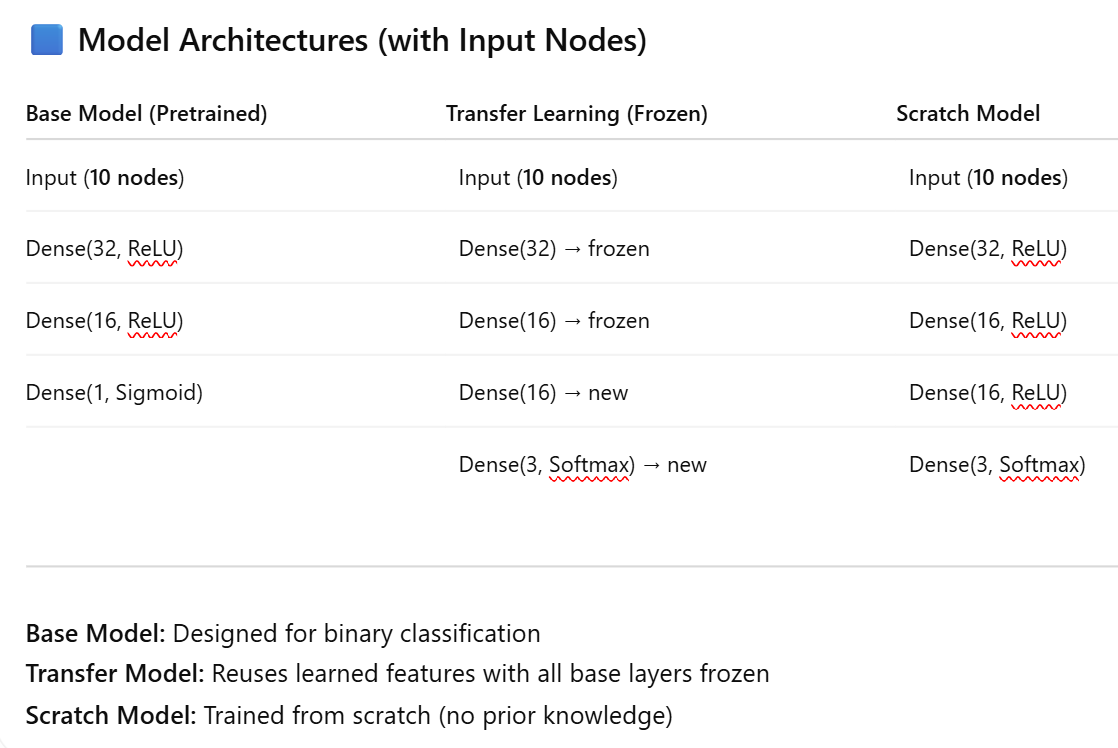

Summary Insight

👉 The base model learns general shift detection,
but the new task requires more detailed classification,
which makes it harder and explains performance differences.

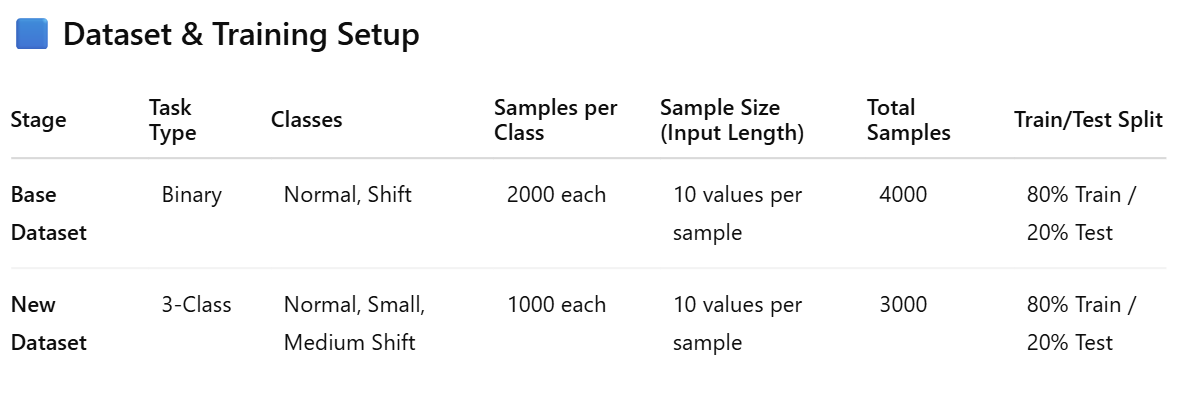

In [ ]:
!pip install numpy scikit-learn tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.2 MB/s eta 0:00:000m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 98.1 MB/s eta 0:00:000m eta 0:00:0101:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 97.1 MB/s eta 0:00:000m eta 0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 7.7 MB/s eta 0:00:000m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 101.2 MB/s eta 0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 96.7 MB/s eta 0:00:000m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 84.6 MB/s eta 0:00:000m eta 0:00:010:00:01
   ━━━━━━━━━━━

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================================================
# 1. Set random seeds
# =========================================================
np.random.seed(42)
tf.random.set_seed(42)

# =========================================================
# 2. Create base dataset (binary classification)
#    Task: Normal vs Shifted
# =========================================================
n_base = 2000
sample_length = 10

# Class 0: Normal process
X0_base = np.random.normal(loc=0.0, scale=1.0, size=(n_base, sample_length))
y0_base = np.zeros(n_base)

# Class 1: Shifted process
X1_base = np.random.normal(loc=1.0, scale=1.0, size=(n_base, sample_length))
y1_base = np.ones(n_base)

X_base = np.vstack((X0_base, X1_base))
y_base = np.hstack((y0_base, y1_base))

# Split base dataset
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42, stratify=y_base
)

# =========================================================
# 3. Build and train base model
# =========================================================
base_input = Input(shape=(sample_length,), name="base_input")
x = Dense(32, activation='relu', name="base_dense_1")(base_input)
x = Dense(16, activation='relu', name="base_dense_2")(x)
base_output = Dense(1, activation='sigmoid', name="base_output")(x)

base_model = Model(inputs=base_input, outputs=base_output)

base_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Training base model...")
base_model.fit(
    Xb_train, yb_train,
    validation_data=(Xb_test, yb_test),
    epochs=10, #Epoch: One full pass through the entire dataset.

    batch_size=32, #Batch size: The number of samples processed before the model updates its weights.
    verbose=1
)

# Evaluate base model
base_pred_prob = base_model.predict(Xb_test)
base_pred = (base_pred_prob > 0.5).astype(int).flatten()

base_acc = accuracy_score(yb_test, base_pred)
base_cm = confusion_matrix(yb_test, base_pred)

print("\n=================================================")
print("BASE MODEL RESULTS (BINARY)")
print("=================================================")
print(f"Base Model Accuracy: {base_acc:.4f}")
print("Base Model Confusion Matrix:")
print(base_cm)

# =========================================================
# 4. Create new dataset (3-class classification)
#    Task: Normal vs Small Shift vs Medium Shift
# =========================================================
n_new = 1000

# Class 0: Normal
X0_new = np.random.normal(loc=0.0, scale=1.0, size=(n_new, sample_length))
y0_new = np.zeros(n_new)

# Class 1: Small shift
X1_new = np.random.normal(loc=0.5, scale=1.0, size=(n_new, sample_length))
y1_new = np.ones(n_new)

# Class 2: Medium shift
X2_new = np.random.normal(loc=1.0, scale=1.0, size=(n_new, sample_length))
y2_new = np.full(n_new, 2)

X_new = np.vstack((X0_new, X1_new, X2_new))
y_new = np.hstack((y0_new, y1_new, y2_new)).astype(int)

# One-hot encode labels(It turns class labels into vectors so the model can learn multiple classes.)
y_new_cat = to_categorical(y_new, num_classes=3)

# Split new dataset
Xn_train, Xn_test, yn_train_cat, yn_test_cat, yn_train, yn_test = train_test_split(
    X_new, y_new_cat, y_new, test_size=0.2, random_state=42, stratify=y_new
)

# =========================================================
# 5. Build transfer learning model using frozen base layers
# =========================================================
# Freeze all layers from base model
for layer in base_model.layers:
    layer.trainable = False

# Use feature extractor from base model (up to second hidden layer)
frozen_features = base_model.get_layer("base_dense_2").output

# Add new layers for 3-class classification
t = Dense(16, activation='relu', name="transfer_dense")(frozen_features)
transfer_output = Dense(3, activation='softmax', name="transfer_output")(t)

transfer_model = Model(inputs=base_model.input, outputs=transfer_output)

transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining transfer learning model with frozen base layers...")
transfer_model.fit(
    Xn_train, yn_train_cat,
    validation_data=(Xn_test, yn_test_cat),
    epochs=10,
    batch_size=32,
    verbose=1
)

# Predict transfer model
transfer_pred_prob = transfer_model.predict(Xn_test)
transfer_pred = np.argmax(transfer_pred_prob, axis=1)

transfer_acc = accuracy_score(yn_test, transfer_pred)
transfer_cm = confusion_matrix(yn_test, transfer_pred)

# =========================================================
# 6. Build and train scratch model for same 3-class task
# =========================================================
scratch_input = Input(shape=(sample_length,), name="scratch_input")
s = Dense(32, activation='relu', name="scratch_dense_1")(scratch_input)
s = Dense(16, activation='relu', name="scratch_dense_2")(s)
s = Dense(16, activation='relu', name="scratch_dense_3")(s)
scratch_output = Dense(3, activation='softmax', name="scratch_output")(s)

scratch_model = Model(inputs=scratch_input, outputs=scratch_output)

scratch_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining scratch model...")
scratch_model.fit(
    Xn_train, yn_train_cat,
    validation_data=(Xn_test, yn_test_cat),
    epochs=10,
    batch_size=32,
    verbose=1
)

# Predict scratch model
scratch_pred_prob = scratch_model.predict(Xn_test)
scratch_pred = np.argmax(scratch_pred_prob, axis=1)

scratch_acc = accuracy_score(yn_test, scratch_pred)
scratch_cm = confusion_matrix(yn_test, scratch_pred)

# =========================================================
# 7. Compare results
# =========================================================
print("\n=================================================")
print("COMPARISON OF 3-CLASS MODELS")
print("=================================================")
print(f"Transfer Learning Model Accuracy: {transfer_acc:.4f}")
print(f"Scratch Model Accuracy:           {scratch_acc:.4f}")

print("\n-------------------------------------------------")
print("Transfer Learning Confusion Matrix")
print("-------------------------------------------------")
print(transfer_cm)

print("\n-------------------------------------------------")
print("Scratch Model Confusion Matrix")
print("-------------------------------------------------")
print(scratch_cm)

# =========================================================
# 8. Classification reports
# =========================================================
class_names = ["Normal", "Small Shift", "Medium Shift"]

print("\n-------------------------------------------------")
print("Transfer Learning Classification Report")
print("-------------------------------------------------")
print(classification_report(yn_test, transfer_pred, target_names=class_names))

print("\n-------------------------------------------------")
print("Scratch Model Classification Report")
print("-------------------------------------------------")
print(classification_report(yn_test, scratch_pred, target_names=class_names))

# =========================================================
# 9. Show which layers are frozen
# =========================================================
print("\n=================================================")
print("LAYER TRAINABILITY STATUS")
print("=================================================")
for layer in transfer_model.layers:
    print(f"{layer.name}: trainable = {layer.trainable}")

I0000 00:00:1775968477.229199    3669 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775968477.287393    3669 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775968478.783277    3669 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Training base model...
Epoch 1/10


E0000 00:00:1775968480.011607    3669 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7350 - loss: 0.5086 - val_accuracy: 0.9025 - val_loss: 0.2992
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9187 - loss: 0.2347 - val_accuracy: 0.9350 - val_loss: 0.1701
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9309 - loss: 0.1765 - val_accuracy: 0.9388 - val_loss: 0.1458
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9353 - loss: 0.1627 - val_accuracy: 0.9425 - val_loss: 0.1383
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9397 - loss: 0.1561 - val_accuracy: 0.9463 - val_loss: 0.1356
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9400 - loss: 0.1517 - val_accuracy: 0.9450 - val_loss: 0.1339
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9425 - loss: 0.1482 - val_accuracy: 0.9438 - val_loss: 0.1335
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9428 - loss: 0.1455 - val_accuracy: 0.9475 - val_

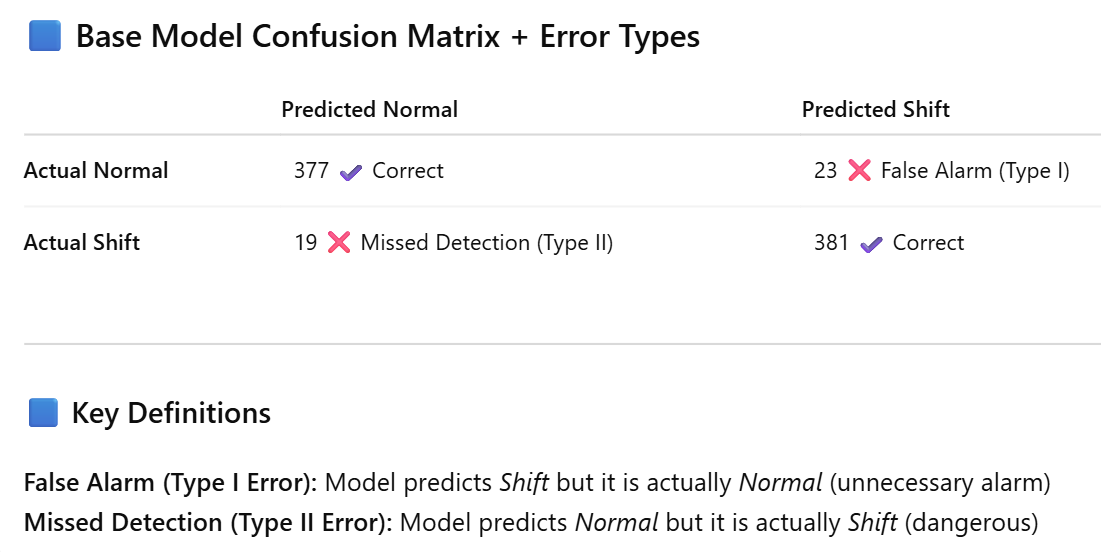

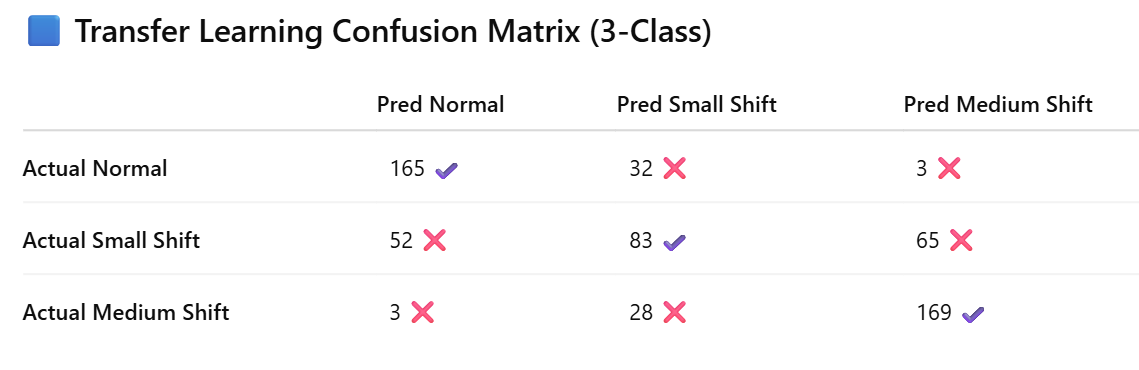

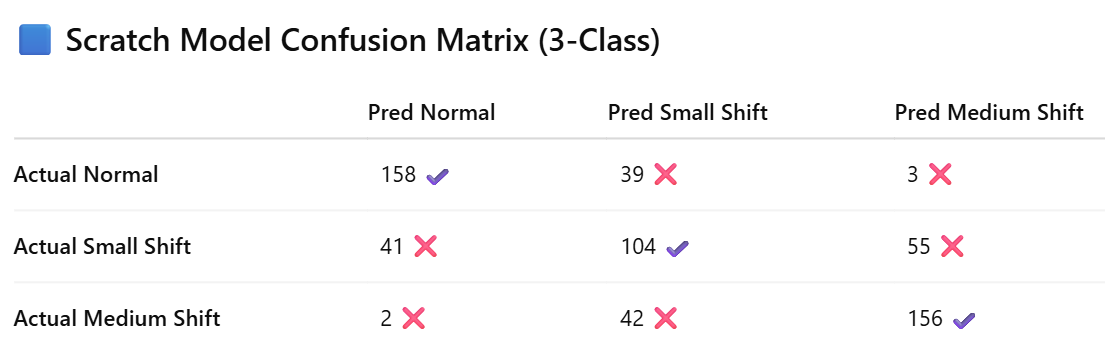

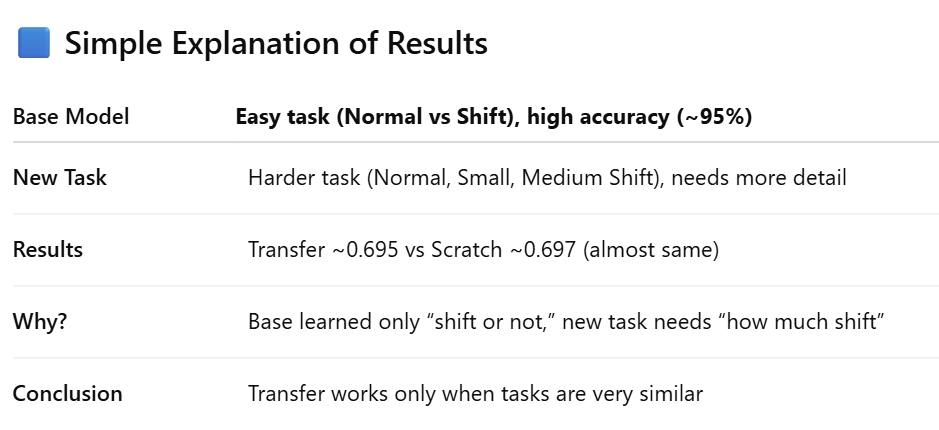

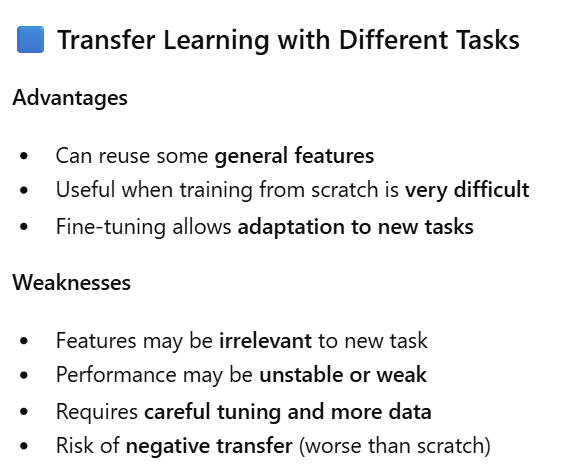

## Transfer Learning with Similar Tasks

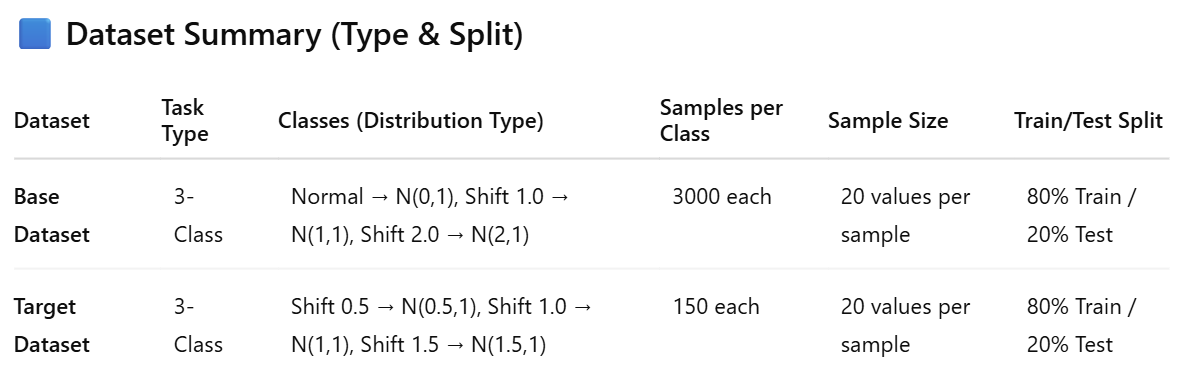

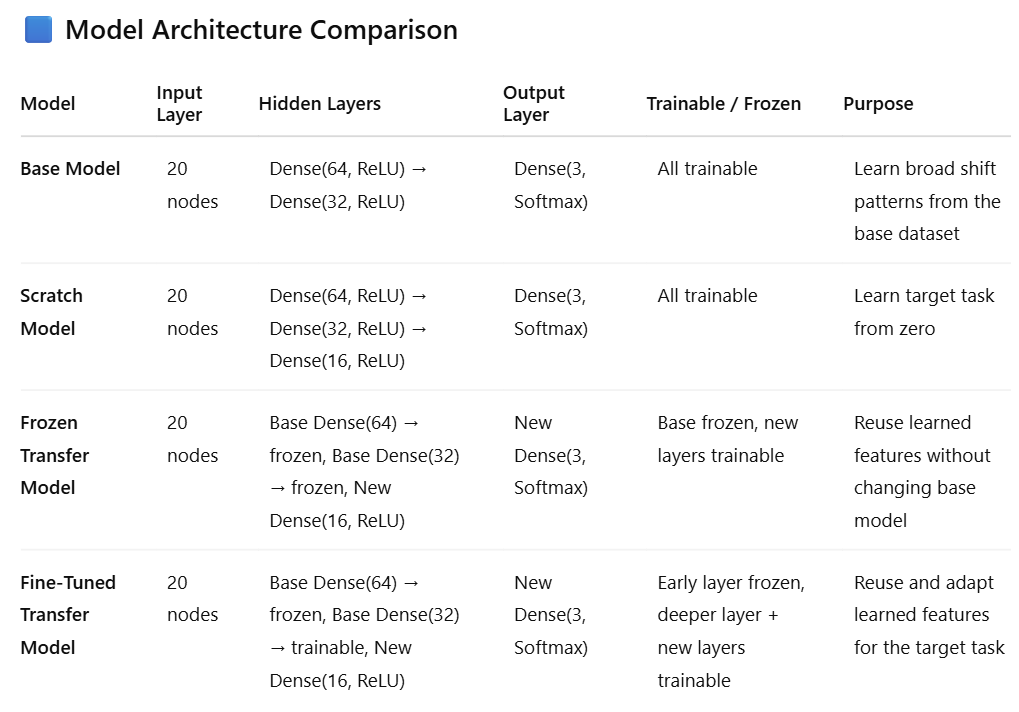

Base learns general patterns, Scratch starts from zero, Frozen reuses fixed knowledge, and Fine-Tune reuses plus adapts knowledge

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, clone_model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================================================
# 1. Reproducibility
# =========================================================
np.random.seed(42)
tf.random.set_seed(42)

# =========================================================
# 2. Helper function: print evaluation results
# =========================================================
def evaluate_model(model, X_test, y_test_true, class_names, title):
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    acc = accuracy_score(y_test_true, y_pred)
    cm = confusion_matrix(y_test_true, y_pred)
    cr = classification_report(y_test_true, y_pred, target_names=class_names)

    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)
    print(f"Accuracy: {acc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(cr)

    return acc, cm, cr

# =========================================================
# 3. Create BASE dataset
#    Base task: broad shift classification
# =========================================================
sample_length = 20
n_base_per_class = 3000

# Base classes:
# 0 = Normal        -> N(0.0, 1)
# 1 = Shift 1.0     -> N(1.0, 1)
# 2 = Shift 2.0     -> N(2.0, 1)

X0_base = np.random.normal(loc=0.0, scale=1.0, size=(n_base_per_class, sample_length))
y0_base = np.zeros(n_base_per_class, dtype=int)

X1_base = np.random.normal(loc=1.0, scale=1.0, size=(n_base_per_class, sample_length))
y1_base = np.ones(n_base_per_class, dtype=int)

X2_base = np.random.normal(loc=2.0, scale=1.0, size=(n_base_per_class, sample_length))
y2_base = np.full(n_base_per_class, 2, dtype=int)

X_base = np.vstack((X0_base, X1_base, X2_base))
y_base = np.hstack((y0_base, y1_base, y2_base))
y_base_cat = to_categorical(y_base, num_classes=3)

Xb_train, Xb_test, yb_train_cat, yb_test_cat, yb_train, yb_test = train_test_split(
    X_base, y_base_cat, y_base,
    test_size=0.2,
    random_state=42,
    stratify=y_base
)

# =========================================================
# 4. Build and train BASE model
# =========================================================
base_input = Input(shape=(sample_length,), name="base_input")
x = Dense(64, activation='relu', name="base_dense_1")(base_input)
x = Dense(32, activation='relu', name="base_dense_2")(x)
base_output = Dense(3, activation='softmax', name="base_output")(x)

base_model = Model(inputs=base_input, outputs=base_output)

base_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training base model...")
base_model.fit(
    Xb_train, yb_train_cat,
    validation_data=(Xb_test, yb_test_cat),
    epochs=15,
    batch_size=32,
    verbose=1
)

base_class_names = ["Normal", "Shift 1.0", "Shift 2.0"]
base_acc, base_cm, base_cr = evaluate_model(
    base_model, Xb_test, yb_test, base_class_names, "BASE MODEL RESULTS"
)

# =========================================================
# 5. Create TARGET dataset
#    Same target task for ALL compared models
# =========================================================
n_target_per_class = 150

# Target classes:
# 0 = Shift 0.5     -> N(0.5, 1)
# 1 = Shift 1.0     -> N(1.0, 1)
# 2 = Shift 1.5     -> N(1.5, 1)

X0_target = np.random.normal(loc=0.5, scale=1.0, size=(n_target_per_class, sample_length))
y0_target = np.zeros(n_target_per_class, dtype=int)

X1_target = np.random.normal(loc=1.0, scale=1.0, size=(n_target_per_class, sample_length))
y1_target = np.ones(n_target_per_class, dtype=int)

X2_target = np.random.normal(loc=1.5, scale=1.0, size=(n_target_per_class, sample_length))
y2_target = np.full(n_target_per_class, 2, dtype=int)

X_target = np.vstack((X0_target, X1_target, X2_target))
y_target = np.hstack((y0_target, y1_target, y2_target))
y_target_cat = to_categorical(y_target, num_classes=3)

Xt_train, Xt_test, yt_train_cat, yt_test_cat, yt_train, yt_test = train_test_split(
    X_target, y_target_cat, y_target,
    test_size=0.2,
    random_state=42,
    stratify=y_target
)

target_class_names = ["Shift 0.5", "Shift 1.0", "Shift 1.5"]

# =========================================================
# 6. SCRATCH model
# =========================================================
scratch_input = Input(shape=(sample_length,), name="scratch_input")
s = Dense(64, activation='relu', name="scratch_dense_1")(scratch_input)
s = Dense(32, activation='relu', name="scratch_dense_2")(s)
s = Dense(16, activation='relu', name="scratch_dense_3")(s)
scratch_output = Dense(3, activation='softmax', name="scratch_output")(s)

scratch_model = Model(inputs=scratch_input, outputs=scratch_output)

scratch_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining scratch model on target task...")
scratch_model.fit(
    Xt_train, yt_train_cat,
    validation_data=(Xt_test, yt_test_cat),
    epochs=20,
    batch_size=16,
    verbose=1
)

scratch_acc, scratch_cm, scratch_cr = evaluate_model(
    scratch_model, Xt_test, yt_test, target_class_names, "SCRATCH MODEL RESULTS"
)

# =========================================================
# 7. FROZEN TRANSFER model
#    Reuse base model weights, freeze base layers, add new head
# =========================================================
# Rebuild base architecture and load trained weights
frozen_base = clone_model(base_model)
frozen_base.set_weights(base_model.get_weights())

# Freeze all pretrained base layers
for layer in frozen_base.layers:
    layer.trainable = False

# Use learned representation from base_dense_2
frozen_features = frozen_base.get_layer("base_dense_2").output
f = Dense(16, activation='relu', name="frozen_transfer_dense")(frozen_features)
frozen_transfer_output = Dense(3, activation='softmax', name="frozen_transfer_output")(f)

frozen_transfer_model = Model(inputs=frozen_base.input, outputs=frozen_transfer_output)

frozen_transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining frozen transfer model on target task...")
frozen_transfer_model.fit(
    Xt_train, yt_train_cat,
    validation_data=(Xt_test, yt_test_cat),
    epochs=20,
    batch_size=16,
    verbose=1
)

frozen_acc, frozen_cm, frozen_cr = evaluate_model(
    frozen_transfer_model, Xt_test, yt_test, target_class_names, "FROZEN TRANSFER MODEL RESULTS"
)

# =========================================================
# 8. FINE-TUNED TRANSFER model
#    Freeze first layer, allow deeper layer adaptation
# =========================================================
fine_base = clone_model(base_model)
fine_base.set_weights(base_model.get_weights())

# Freeze only early layer(s), fine-tune later representation
fine_base.get_layer("base_dense_1").trainable = False
fine_base.get_layer("base_dense_2").trainable = True
fine_base.get_layer("base_output").trainable = False

fine_features = fine_base.get_layer("base_dense_2").output
ft = Dense(16, activation='relu', name="fine_tune_dense")(fine_features)
fine_output = Dense(3, activation='softmax', name="fine_tune_output")(ft)

fine_tune_model = Model(inputs=fine_base.input, outputs=fine_output)

fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining fine-tuned transfer model on target task...")
fine_tune_model.fit(
    Xt_train, yt_train_cat,
    validation_data=(Xt_test, yt_test_cat),
    epochs=20,
    batch_size=16,
    verbose=1
)

fine_acc, fine_cm, fine_cr = evaluate_model(
    fine_tune_model, Xt_test, yt_test, target_class_names, "FINE-TUNED TRANSFER MODEL RESULTS"
)

# =========================================================
# 9. Final comparison
# =========================================================
print("\n" + "=" * 60)
print("FINAL COMPARISON ON THE SAME TARGET TASK")
print("=" * 60)
print(f"Scratch Accuracy:             {scratch_acc:.4f}")
print(f"Frozen Transfer Accuracy:     {frozen_acc:.4f}")
print(f"Fine-Tuned Transfer Accuracy: {fine_acc:.4f}")

print("\nExpected teaching interpretation:")
print("- Scratch: learns target task from zero")
print("- Frozen transfer: reuses pretrained knowledge without adapting base layers")
print("- Fine-tuned transfer: reuses pretrained knowledge and adapts deeper layers")

# =========================================================
# 10. Layer trainability check
# =========================================================
print("\n" + "=" * 60)
print("FROZEN TRANSFER LAYER STATUS")
print("=" * 60)
for layer in frozen_transfer_model.layers:
    print(f"{layer.name}: trainable = {layer.trainable}")

print("\n" + "=" * 60)
print("FINE-TUNED TRANSFER LAYER STATUS")
print("=" * 60)
for layer in fine_tune_model.layers:
    print(f"{layer.name}: trainable = {layer.trainable}")

Training base model...
Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8507 - loss: 0.3813 - val_accuracy: 0.9428 - val_loss: 0.1657
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9519 - loss: 0.1337 - val_accuracy: 0.9572 - val_loss: 0.1127
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9644 - loss: 0.1023 - val_accuracy: 0.9617 - val_loss: 0.0937
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9699 - loss: 0.0870 - val_accuracy: 0.9667 - val_loss: 0.0850
Epoch 5/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9726 - loss: 0.0771 - val_accuracy: 0.9689 - val_loss: 0.0797
Epoch 6/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9756 - loss: 0.0703 - val_accuracy: 0.9700 - val_loss: 0.0759
Epoch 7/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9778 - loss: 0.0652 - val_accuracy: 0.9717 - val_loss: 0.0742
Epoch 8/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9794 - loss: 0.

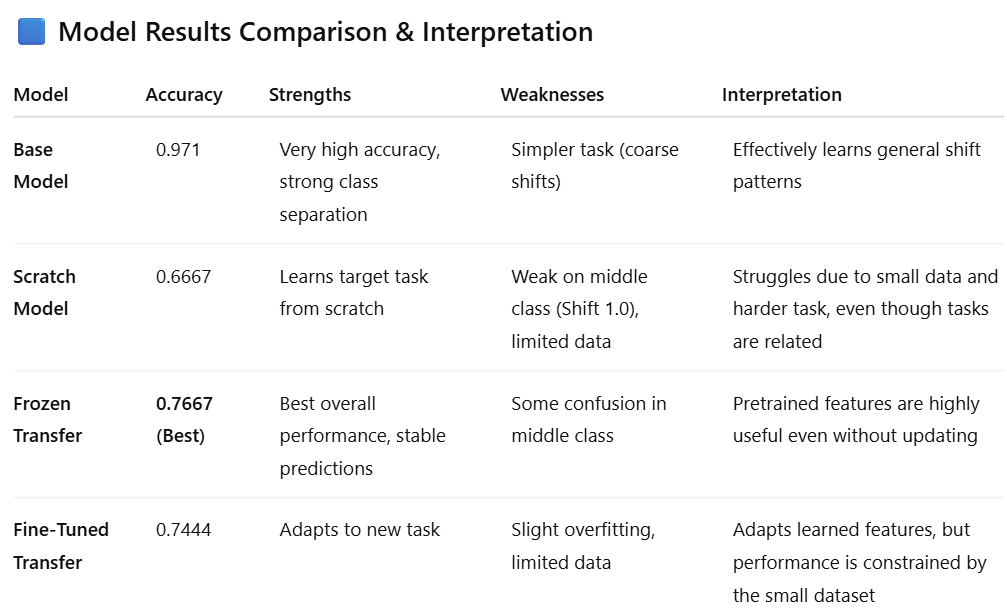